# Example: Drift of Maximum Sharpe Ratio Portfolios
In this example, we compute the maximum Sharpe ratio (tangent) portfolio $\mathcal{T}$ for a set of firms from single index model inputs, hold its share counts fixed through 2025, and measure how far the portfolio weights drift from the allocation we chose.

> __Learning Objectives:__
> 
> By the end of this example, you will be able to:
> * __Compute the maximum Sharpe ratio portfolio:__ Build the tangent portfolio from the single index model expected growth rates and covariance matrix by normalizing the risky weights of a risky and risk-free solution, as in L6b.
> * __Track portfolio drift:__ Show that the weights change with prices even though the share counts are held constant, and measure how far the portfolio has moved with the half-L1 distance from the initial allocation.
> * __Analyze the consequences of drift:__ Compute the portfolio's alpha and beta through the year as the allocation drifts away from the tangent portfolio.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) for calendar year 2025 (`01-02-2025` to `12-31-2025`), along with data for several exchange-traded funds during that period. This is the testing period: the single index model parameters we load below were estimated on 2014 to 2024, so nothing in 2025 was seen by the models.

Let's load the `original_dataset::Dict{String,DataFrame}` by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet).

In [2]:
original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"] # load the original dataset (testing)

Dict{String, DataFrame} with 483 entries:
  "NI"   => 250×8 DataFrame…
  "EMR"  => 250×8 DataFrame…
  "CTAS" => 250×8 DataFrame…
  "HSIC" => 250×8 DataFrame…
  "KIM"  => 250×8 DataFrame…
  "PLD"  => 250×8 DataFrame…
  "IEX"  => 250×8 DataFrame…
  "BAC"  => 250×8 DataFrame…
  "CBOE" => 250×8 DataFrame…
  "EXR"  => 250×8 DataFrame…
  "NCLH" => 250×8 DataFrame…
  "CVS"  => 250×8 DataFrame…
  "DRI"  => 250×8 DataFrame…
  "DTE"  => 250×8 DataFrame…
  "ZION" => 250×8 DataFrame…
  "AVY"  => 250×8 DataFrame…
  "EW"   => 250×8 DataFrame…
  "EA"   => 250×8 DataFrame…
  "NWSA" => 250×8 DataFrame…
  "BBWI" => 250×8 DataFrame…
  "CAG"  => 250×8 DataFrame…
  "GPC"  => 250×8 DataFrame…
  "FCX"  => 250×8 DataFrame…
  "GILD" => 250×8 DataFrame…
  "INFO" => 250×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # maximum number of trading days in our dataset

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # check if ticker has maximum trading days
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers_price_data = keys(dataset) |> collect |> sort;

Finally, let's load the single index model parameters estimated in L6a from the 2014 to 2024 training data. The archive holds one `NamedTuple` per ticker (fields `alpha`, `beta`, `training_variance`, and others) together with the training-period sample mean `market_mean` and variance `market_variance` of the market growth rate. We store the per-ticker parameters in the `sim_model_parameters::Dict{String,NamedTuple}` variable and the market moments in `g_market_mean` and `σ²_market`:

In [6]:
sim_model_parameters, g_market_mean, σ²_market = let

    # initialize -
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture

    # return -
    (archive["data"], archive["market_mean"], archive["market_variance"]);
end;

Now let's get a list of all tickers for which we have single index model parameters:

In [7]:
tickers_that_we_sim_sim_data_for = keys(sim_model_parameters) |> collect |> sort;

We need to use only the tickers for which we have both price data and SIM parameters. We'll compute the intersection of the two lists and store the result in the `list_of_tickers::Array{String,1}` variable:

In [8]:
list_of_tickers = intersect(tickers_that_we_sim_sim_data_for, list_of_tickers_price_data);

In [9]:
list_of_tickers

417-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values:

In [10]:
Δt = (1.0/252.0); # time step for 1-trading day (units: years)
W₀ = 1000.0; # initial wealth W_P(0) (units: USD)
g_f = 0.041; # risk-free growth rate (units: 1/years): continuously compounded equivalent of a one-year Treasury yield of about 4.16% at the end of 2024, as in L5b and L6b

___

## Task 1: Compute the Maximum Sharpe Ratio (Tangent) Portfolio
In this task, we compute the maximum Sharpe ratio portfolio, i.e., the tangent portfolio $\mathcal{T}$ of L5b and L6b, from the single index model parameters we loaded above, the same way the other L7a examples do.

Let's start by specifying the firms we hold. We use the same $|\mathcal{P}| = 13$ firms as L5b and L6b, stored in the `my_list_of_tickers::Array{String,1}` array:

In [11]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b and L6b

### SIM inputs: expected growth rates and covariance
Next, we compute the expected growth rate vector and the covariance matrix from the single index model, exactly as in L6b: the mean vector is $\hat{\mathbf{g}}_{\text{SIM}} = \hat{\boldsymbol{\alpha}} + \hat{\boldsymbol{\beta}}\,g^{\prime}_{M}$ and the covariance is the rank-one plus diagonal matrix $\hat{\mathbf{\Sigma}}_{g,\text{SIM}} = s^{2}_{g,M}\,\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g}$, where $g^{\prime}_{M}$ and $s^{2}_{g,M}$ are the training-period sample mean and variance of the market growth rate and $\hat{\mathbf{D}}_{g}$ holds the residual variances $s^{2}_{g,\varepsilon,i}$ on its diagonal. We store these in the `ĝ_sim::Array{Float64,1}` and `Σ̂_g_sim::Array{Float64,2}` variables:

In [12]:
ĝ_sim, Σ̂_g_sim, α̂, β̂ = let

    # SIM parameters for our firms -
    α̂ = [sim_model_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_model_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_model_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)

    # SIM inputs -
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)

    (ĝ_sim, Σ̂_g_sim, α̂, β̂); # return
end;

Now we compute the tangent portfolio. L6b showed that every solution of the risky and risk-free minimum-variance problem lies on one ray from the risk-free asset, so the tangent portfolio is the normalized risky weight vector of any solution above $g_{f}$; we solve [the `MyMarkowitzRiskyRiskFreePortfolioChoiceProblem`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyRiskFreePortfolioChoiceProblem) once at a target of $0.30$ per year and normalize. We store the result in the `sharpe_solution::NamedTuple` variable (fields `w`, `g`, `σ`, `sharpe_ratio`); the Sharpe ratio is in growth-rate units (the one-day convention of L5b), and dividing by $\sqrt{\Delta{t}}$ gives the annualized value quoted from L6b onward:

In [13]:
sharpe_solution = let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0; # 0 ≤ wᵢ ≤ 1 on the risky weights
    initial = (1/number_of_assets)*ones(number_of_assets);
    problem_rf = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, risk_free_rate = g_f, R = 0.30));
    w_risky = solve(problem_rf)["argmax"];
    @assert sum(w_risky) > 1e-2
    w = max.(w_risky, 0.0) |> w -> w ./ sum(w); # tangent portfolio by normalization (ray property, L6b); solver noise of order 1e-9 clipped
    g = ĝ_sim'*w; σ = sqrt(w'*Σ̂_g_sim*w);
    (w = w, g = g, σ = σ, sharpe_ratio = (g - g_f)/σ); # return
end;
println("Tangent portfolio: E[g] = $(round(sharpe_solution.g, digits=4)) 1/yr, σ_g = $(round(sharpe_solution.σ, digits=4)) 1/yr, Sharpe ratio (growth-rate units) = $(round(sharpe_solution.sharpe_ratio, digits=4)), annualized = $(round(sharpe_solution.sharpe_ratio/sqrt(Δt), digits=3))")

Tangent portfolio: E[g] = 0.3944 1/yr, σ_g = 4.2382 1/yr, Sharpe ratio (growth-rate units) = 0.0834, annualized = 1.324


__What's in the tangent portfolio?__ Let's look at its makeup. First, we compute the number of shares of each asset that our initial wealth buys on the first trading day of 2025, $n_{i} = w_{i}\,W_{\mathcal{P}}(0)/S_{i}(0)$, where $S_{i}(0)$ is the close price on that day (the engine of the L7a lecture trades at the close, so every L7a example marks and trades at close prices). We store the share counts in the `n₀::Array{Float64,1}` variable:

In [14]:
n₀ = let
    
    # initialize -
    number_of_assets = length(my_list_of_tickers);
    n = zeros(Float64, number_of_assets); # number of shares to purchase for each asset
    w = sharpe_solution.w; # tangent weights
    prices = Array{Float64,1}(undef, number_of_assets); # prices vector

    # get prices for each asset -
    for i ∈ eachindex(my_list_of_tickers)
        ticker = my_list_of_tickers[i];
        prices[i] = dataset[ticker][1, :close]; # close price on the first trading day of 2025
    end

    # get the number of shares to purchase for each asset -
    for i in 1:number_of_assets
        n[i] = W₀ * w[i] / prices[i];
    end

    n; # return
end;

Let's build a table to summarize the tangent portfolio allocation. The table shows the ticker, alpha, beta, allocation weight, close price on the first trading day of 2025, number of shares, and the dollar position for each asset in the portfolio:

In [15]:
let

    # initialize -
    df = DataFrame();

    for i ∈ eachindex(my_list_of_tickers)
        ticker = my_list_of_tickers[i];
        α = sim_model_parameters[ticker].alpha;
        β = sim_model_parameters[ticker].beta;
        price = dataset[ticker][1, :close]; # close price on the first trading day of 2025
        weight = round(sharpe_solution.w[i], digits=4);
        shares = n₀[i] |> x -> round(x, digits=4);
       
        row_df = (
            ticker = ticker,
            α = round(α, digits=4),
            β = round(β, digits=4),
            w = weight,
            price = round(price, digits=4),
            n = shares,
            position = round(shares * price, digits=2),
        )
        push!(df, row_df);
    end

    beta_vec = df[:,:β] |> collect;
    alpha_vec = df[:,:α] |> collect;
    w_vec = df[:,:w] |> collect;

    # compute the total -
    total = df[:,:w] |> sum
    last_row = (
        ticker = "portfolio",
        α = round(dot(alpha_vec,w_vec), digits=4),
        β = round(dot(beta_vec,w_vec), digits=4),
        w = round(total, digits=4),
        price = 0.0,
        n = round(sum(n₀), digits=4),
        position = round(sum(df[:,:position]), digits=2),
    )
    push!(df,last_row)

    pretty_table(df, fit_table_in_display_vertically = false,
         table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ----------- --------- --------- --------- --------- --------- ----------
     ticker         α         β         w     price         n   position 
     String   Float64   Float64   Float64   Float64   Float64    Float64 
 ----------- --------- --------- --------- --------- --------- ----------
       AAPL    0.1061    1.1946    0.2027    243.85    0.8314     202.74
       MSFT    0.0999     1.152    0.2203    418.58    0.5263      220.3
       INTC   -0.1484    1.1843       0.0     20.22       0.0        0.0
         MU   -0.0532    1.6953       0.0     87.33       0.0        0.0
        AMD    0.1275    1.7392    0.0405    120.63    0.3361      40.54
       NVDA    0.3468    1.7493    0.5364    138.31    3.8782     536.39
         GS   -0.0326      1.31       0.0    574.97       0.0        0.0
        BAC   -0.0545    1.3594       0.0     44.29       0.0        0.0
        WFC   -0.0914    1.2383       0.0     70.19       0.0        0.0
          C   -0.1334    1.5008       0.0     6

___

## Task 2: Compute the Drift of the Tangent Portfolio
In this task, we hold the share counts $n_{i}$ fixed for all of 2025 and compute how the portfolio weights drift. The weight of asset $i$ on day $t$ is the fraction of the portfolio's value it represents:
$$
w_{i}(t) = \frac{n_{i}\,S_{i}(t)}{\sum_{j\in\mathcal{P}}n_{j}\,S_{j}(t)}\qquad\forall{i}\in\mathcal{P}
$$
Substituting $n_{i} = w_{i}(0)\,W_{\mathcal{P}}(0)/S_{i}(0)$ shows that the drifted weight depends only on the initial weights and the price relatives:
$$
w_{i}(t) = \frac{w_{i}(0)\,\left(S_{i}(t)/S_{i}(0)\right)}{\sum_{j\in\mathcal{P}} w_{j}(0)\,\left(S_{j}(t)/S_{j}(0)\right)}
$$
so the weights stay put only if every asset has the same price relative, which never happens. We measure the drift on day $t$ by the half-$L^{1}$ distance from the initial allocation, $\tfrac{1}{2}\sum_{i\in\mathcal{P}}|w_{i}(t) - w_{i}(0)|$, which is the fraction of wealth that would have to be traded to return to the initial weights.

We track the portfolio through every trading day of 2025. Let's store the number of days in the `number_of_days::Int64` variable:

In [16]:
number_of_days = nrow(dataset["AAPL"]); # every trading day of 2025

Next, let's compute the value of each position and the total value of the portfolio on each day, starting from the initial allocation. We store this data in the `portfolio_performance_array::Array{Float64,2}` array. Each `row` corresponds to a trading day, each `column` to an asset in the portfolio, with the last column holding the total value $W_{\mathcal{P}}(t)$. We use the close price of each asset.

In [17]:
portfolio_performance_array = let
    
    number_of_assets = length(my_list_of_tickers);
    portfolio_performance_array = Array{Float64,2}(undef, number_of_days, number_of_assets + 1)
    for i ∈ eachindex(my_list_of_tickers)
        
        ticker = my_list_of_tickers[i];
        price_df = dataset[ticker];
        nᵢ = n₀[i]
        
        for j ∈ 1:number_of_days
            portfolio_performance_array[j,i] = nᵢ*price_df[j,:close]; # value of this position on day j
        end
    end
    
    # total -
    for i ∈ 1:number_of_days
        portfolio_performance_array[i,end] = sum(portfolio_performance_array[i,1:end-1])
    end
    portfolio_performance_array;
end;

Now, let's compute the performance of investing all our initial wealth in `SPY` on the same day, at the same close price: We store the SPY wealth path in the `SPY_performance_array::Array{Float64,1}` variable:

In [18]:
SPY_performance_array = let

    # initialize -
    SPY_performance_array = Array{Float64,1}(undef, number_of_days);
    SPY_df = dataset["SPY"];
    
    # how many shares of SPY do we buy?
    S₀ = SPY_df[1, :close]; # close price on the first trading day of 2025
    n_SPY = W₀/S₀;

    # compute the performance
    for i ∈ 1:number_of_days
        S = SPY_df[i, :close];
        SPY_performance_array[i] = S*n_SPY;
    end
    SPY_performance_array;
end;

### Visualize
`Unhide` the code block below to see how we visualized the scaled wealth $W_{\mathcal{P}}(t)/W_{\mathcal{P}}(0)$ of the buy-and-hold tangent portfolio versus `SPY` over 2025 (daily close prices).

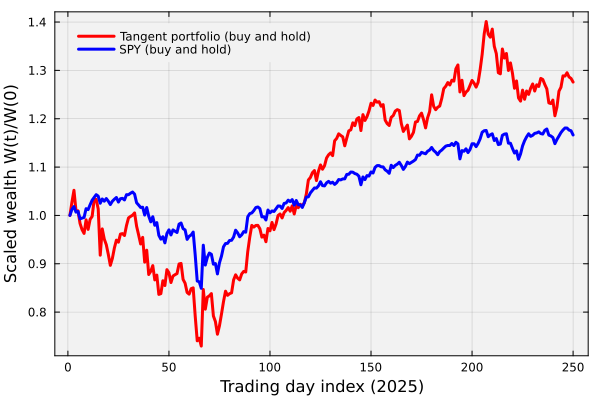

In [19]:
let
    plot((1/W₀).*portfolio_performance_array[:,end], lw=3, 
        c=:red, label="Tangent portfolio (buy and hold)")
    plot!((1/W₀).*SPY_performance_array, lw=3, 
        c=:blue, label="SPY (buy and hold)")
    xlabel!("Trading day index (2025)", fontsize=18)
    ylabel!("Scaled wealth W(t)/W(0)", fontsize=18)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
end

__Hypothesis__: Because prices move, the initial allocation changes over time even though the share counts $n_{i}$ are constant.

Let's compute the `drift_array::Array{Float64,2}` array, which holds the weight $w_{i}(t)$ of each ticker (column) on each trading day (row); the last column holds the sum of the weights, which should be one on every day.

In [20]:
drift_array = let
    w = sharpe_solution.w; # tangent weights
    drift_array = Array{Float64,2}(undef, number_of_days, length(w) + 1)
    for i ∈ 1:number_of_days
        
        total_portfolio_value = portfolio_performance_array[i,end];
        for j ∈ eachindex(my_list_of_tickers)
            drift_array[i,j] = (1/total_portfolio_value).*portfolio_performance_array[i,j]
        end
        drift_array[i,end] = sum(drift_array[i,1:end-1])
    end
    drift_array;
end

250×14 Matrix{Float64}:
 0.202746  0.220317  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.196907  0.216846  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.193641  0.214073  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.199393  0.220115  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.199875  0.221345  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.200225  0.224206  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.200793  0.226238  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.201462  0.22725   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.199602  0.226459  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.195437  0.230131  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.192772  0.227657  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.185498  0.22601   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.180171  0.227371  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  1.0
 ⋮                             ⋱                 ⋮              
 0.185097  0.202975  0.0  0

`Unhide` the code block below to see how we visualize the weights $w_{i}(t)$ of each asset in the portfolio as a function of time. Only assets with a nonzero weight in $\mathcal{T}$ move; assets that start at zero stay at zero.

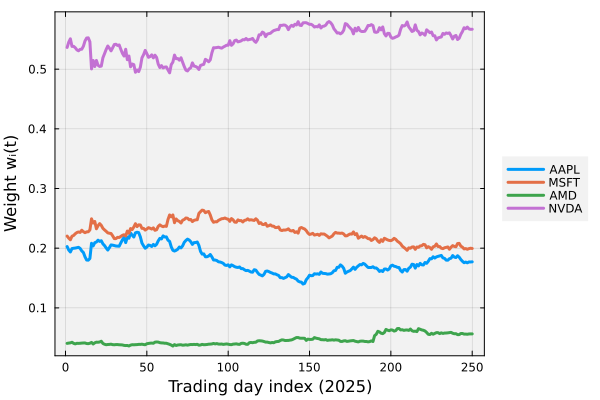

In [21]:
let
    w0 = drift_array[1, 1:end-1];
    held = findall(x -> x > 1e-3, w0); # assets with a nonzero initial weight
    p = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:outerright);
    for i ∈ held
        plot!(p, drift_array[:, i], lw=3, label=my_list_of_tickers[i]);
    end
    xlabel!(p, "Trading day index (2025)", fontsize=18)
    ylabel!(p, "Weight wᵢ(t)", fontsize=18)
    p
end

How far has the portfolio moved from the allocation we chose? Let's compute the half-$L^{1}$ drift $\tfrac{1}{2}\sum_{i}|w_{i}(t)-w_{i}(0)|$ on each day and plot it. This is the fraction of wealth that a rebalance back to $\mathcal{T}$ would have to trade on that day, before costs. We store the daily drift in the `drift_series::Array{Float64,1}` variable; `unhide` the code block below to see how we computed and plotted it.

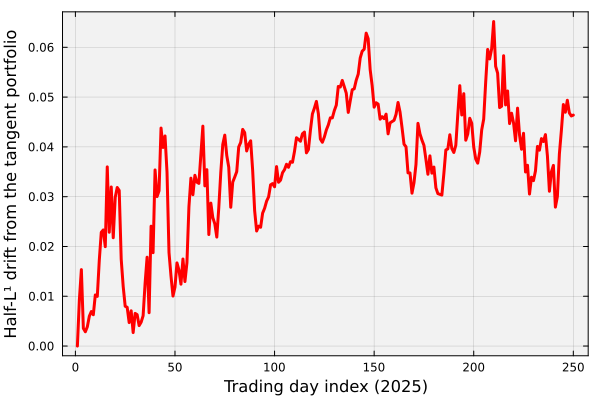

In [22]:
drift_series = let
    w0 = drift_array[1, 1:end-1];
    [0.5*sum(abs.(drift_array[t, 1:end-1] .- w0)) for t ∈ 1:number_of_days];
end;

let
    plot(drift_series, lw=3, c=:red, label="")
    xlabel!("Trading day index (2025)", fontsize=18)
    ylabel!("Half-L¹ drift from the tangent portfolio", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box)
end

Let's look at the weights and the drift at a few dates during the year, and at the portfolio's $\alpha_{\mathcal{P}}(t) = \sum_{i}w_{i}(t)\,\alpha_{i}$ and $\beta_{\mathcal{P}}(t) = \sum_{i}w_{i}(t)\,\beta_{i}$, which drift with the weights:

In [23]:
let
    w0 = drift_array[1, 1:end-1];
    held = findall(x -> x > 1e-3, w0);
    days = [1, 63, 126, 189, number_of_days];
    df = DataFrame(day = days);
    for i ∈ held
        df[!, my_list_of_tickers[i]] = round.(drift_array[days, i], digits=4);
    end
    df[!, "drift"] = round.(drift_series[days], digits=4);
    df[!, "α_P"] = round.([dot(drift_array[t, 1:end-1], α̂) for t ∈ days], digits=4);
    df[!, "β_P"] = round.([dot(drift_array[t, 1:end-1], β̂) for t ∈ days], digits=4);
    pretty_table(df, fit_table_in_display_vertically = false,
         table_format = TextTableFormat(borders = text_table_borders__compact));
end

 ------- --------- --------- --------- --------- --------- --------- ---------
    day      AAPL      MSFT       AMD      NVDA     drift       α_P       β_P 
  Int64   Float64   Float64   Float64   Float64   Float64   Float64   Float64 
 ------- --------- --------- --------- --------- --------- --------- ---------
      1    0.2027    0.2203    0.0405    0.5364       0.0    0.2347    1.5048
     63    0.2134    0.2481    0.0398    0.4987    0.0384    0.2254    1.4823
    126    0.1593    0.2391    0.0414    0.5602    0.0434    0.2403    1.5176
    189    0.1689    0.2144    0.0436     0.573    0.0397    0.2436     1.527
    250    0.1772    0.1995    0.0564    0.5669    0.0464    0.2425    1.5313
 ------- --------- --------- --------- --------- --------- --------- ---------


`Unhide` the code block below to see the portfolio's $\alpha_{\mathcal{P}}(t)$ and $\beta_{\mathcal{P}}(t)$ through 2025.

year-end drift = 0.0464; NVDA weight between 0.494 and 0.58; β_P between 1.479 and 1.542; α_P between 0.2242 and 0.2456 1/yr


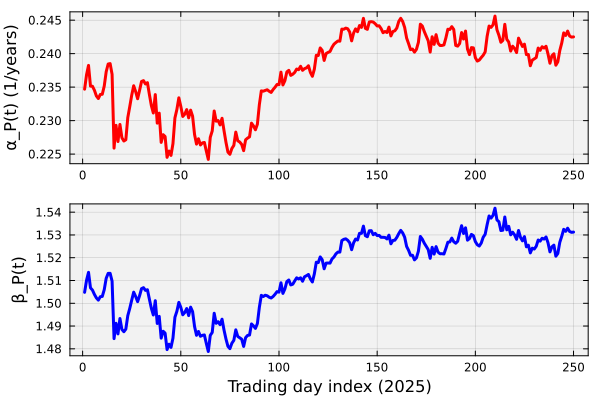

In [24]:
let
    αP = [dot(drift_array[t, 1:end-1], α̂) for t ∈ 1:number_of_days];
    βP = [dot(drift_array[t, 1:end-1], β̂) for t ∈ 1:number_of_days];
    p1 = plot(αP, lw=3, c=:red, label="", ylabel="α_P(t) (1/years)", bg="gray95", background_color_outside="white", framestyle = :box);
    p2 = plot(βP, lw=3, c=:blue, label="", ylabel="β_P(t)", xlabel="Trading day index (2025)", bg="gray95", background_color_outside="white", framestyle = :box);
    println("year-end drift = $(round(drift_series[end], digits=4)); NVDA weight between $(round(minimum(drift_array[:, findfirst(==("NVDA"), my_list_of_tickers)]), digits=3)) and $(round(maximum(drift_array[:, findfirst(==("NVDA"), my_list_of_tickers)]), digits=3)); β_P between $(round(minimum(βP), digits=3)) and $(round(maximum(βP), digits=3)); α_P between $(round(minimum(αP), digits=4)) and $(round(maximum(αP), digits=4)) 1/yr")
    plot(p1, p2, layout=(2,1))
end

___

## Summary
In this example, we computed the tangent portfolio $\mathcal{T}$ from single index model inputs, held its share counts fixed through 2025, and measured how far the weights drifted from the allocation we chose.

> __Key Takeaways:__
> 
> * __Drift is mechanical:__ With constant share counts, the weight of each asset moves with its price relative, so the portfolio leaves the tangent allocation as soon as prices move differently across assets.
> * __The half-L1 distance measures it:__ half the sum of the absolute weight changes is the fraction of wealth a rebalance back to the tangent portfolio would have to trade; it grows through the year and is the quantity a rebalancing rule watches.
> * __Risk exposure drifts with the weights:__ the portfolio's alpha and beta change as the allocation moves, so a portfolio chosen for its Sharpe ratio on the decision date has different growth and risk properties later.

Drift is the first reason a portfolio must be treated as a process rather than a one-time decision; the L7a lecture builds the rebalancing engine that responds to it.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___